In [4]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv('IDTA.csv')
df.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [17]:
df['Depression'].value_counts()

Depression
0    1851
1     203
Name: count, dtype: int64

In [18]:
df['Sleep Duration'] = df['Sleep Duration'].replace({'7-8 hours':7.5, '5-6 hours':5.5, 'More than 8 hours':9, 'Less than 5 hours':4})
df['Dietary Habits'] = df['Dietary Habits'].replace({'Healthy':2, 'Moderate':1, 'Unhealthy':0})
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].replace({'Yes':1, 'No':0})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].replace({'Yes':1, 'No':0})
df['Depression'] = df['Depression'].replace({'Yes':1, 'No':0})
df['Gender']=df['Gender'].replace({'Female':0,'Male':1})

In [19]:
X=df.drop('Depression',axis=1)
y=df['Depression']

In [20]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(y_resampled.value_counts())

Depression
1    1481
0    1481
Name: count, dtype: int64


/Applications/main/pyhton/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Applications/main/pyhton/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

lg_model = LogisticRegression(penalty='l2', solver='liblinear', C=0.01, max_iter=100)
lg_model.fit(X_resampled,y_resampled)

lg_y_pred = lg_model.predict(X_resampled)

lg_prediction_score = classification_report(lg_y_pred,y_resampled)

print(lg_prediction_score)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1399
           1       0.98      0.92      0.95      1563

    accuracy                           0.95      2962
   macro avg       0.95      0.95      0.95      2962
weighted avg       0.95      0.95      0.95      2962



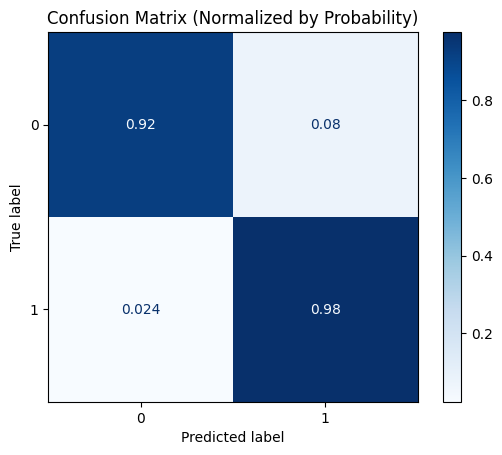

In [28]:
ConfusionMatrixDisplay.from_predictions(y_resampled, lg_y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_resampled,y_resampled)

print("Best C:", grid_search.best_params_)

param_grid = {'gamma': [0.001, 0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(SVC(kernel='rbf', C=100), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_resampled,y_resampled)

print("Best gamma:", grid_search.best_params_)

Best C: {'C': 100}
Best gamma: {'gamma': 1}


In [35]:
from sklearn.svm import SVC

svc_model = SVC(gamma=0.01, C=100,)

svc_model.fit(X_resampled,y_resampled)

svc_y_pred = svc_model.predict(X_resampled)

svc_prediction_score = classification_report(svc_y_pred,y_resampled)

print(svc_prediction_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1481
           1       1.00      1.00      1.00      1481

    accuracy                           1.00      2962
   macro avg       1.00      1.00      1.00      2962
weighted avg       1.00      1.00      1.00      2962



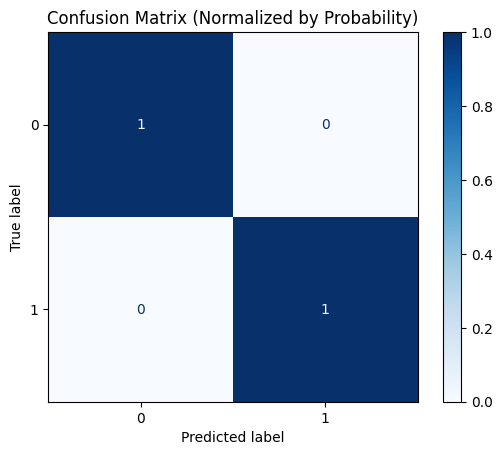

In [33]:
ConfusionMatrixDisplay.from_predictions(y_resampled, svc_y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=None,
    random_state=42
)


dt_model.fit(X_resampled, y_resampled)


dt_y_pred = dt_model.predict(X_resampled)


dt_prediction_score = classification_report(y_resampled, dt_y_pred)

print(dt_prediction_score)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1481
           1       1.00      1.00      1.00      1481

    accuracy                           1.00      2962
   macro avg       1.00      1.00      1.00      2962
weighted avg       1.00      1.00      1.00      2962



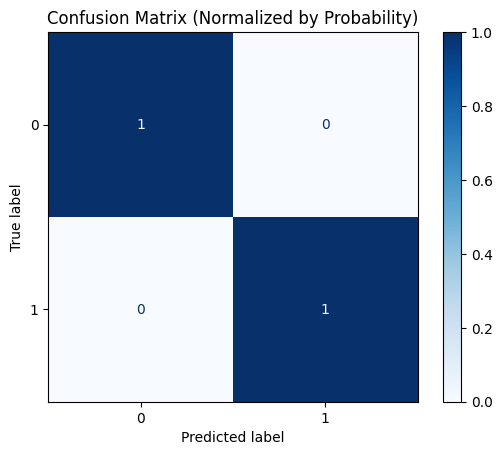

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_resampled, dt_y_pred, cmap='Blues', normalize='true')
plt.title("Confusion Matrix (Normalized by Probability)")
plt.show()